In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

# This version is deliberately less calibrated:
#
#   - no curve is forced to cross at a chosen batch size;
#   - all curves share the same d, T, L2, delta0, and sigma;
#   - only r = L_inf / L_2 is swept.

/var/folders/ck/2h92ww3n7f934h0f58607dljk8_14b/T/ipykernel_34961/1862657819.py:80: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  c = plt.cm.get_cmap("RdYlBu")


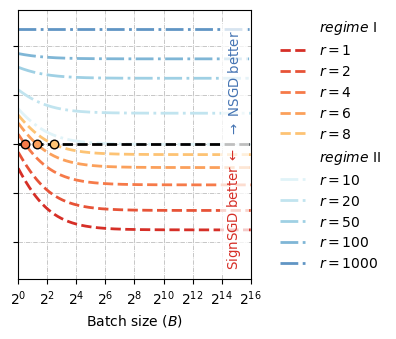

In [ ]:
f = 1
d = 10**3
L2 = 1
T = 10**6
sigma = 0.01
delta0 = 10

f = 2
d = 10**3
L2 = 1000
T = 10**6
sigma = 0.01
delta0 = 10

r_threshold_1 = 1
r_threshold_2 = d ** (1 / 3)
r_threshold_3 = d


def gap_coefficients(r):
    """
    Coefficients for:

        U_2(B) - U_inf(B) = a0 + a1 / sqrt(B) + a2 B.

    Here r = L_inf / L_2.
    """
    Linf = r * L2
    a0 = (sigma**2 * delta0) ** 0.25 * (L2**0.25 - (Linf * d) ** 0.25) / T**0.25
    a1 = sigma**2 / np.sqrt(delta0 * T) * (1 / np.sqrt(L2) - d / np.sqrt(Linf))
    a2 = delta0**0.75 / (np.sqrt(sigma) * T**0.75) * (L2**0.75 - Linf**0.75 / d**0.25)
    return a0, a1, a2


def U_bound(B, L, rho):
    """
    Minimized convergence-bound proxy:

        U = (L delta0)^(1/4) sqrt(rho sigma) / T^(1/4)
            + (rho sigma)^2 / sqrt(L delta0 T B)
            + (L delta0)^(3/4) B / (sqrt(rho sigma) T^(3/4)).
    """
    B = np.asarray(B, dtype=float)
    return (
        (L * delta0) ** 0.25 * np.sqrt(rho * sigma) / T**0.25
        + (rho * sigma) ** 2 / np.sqrt(L * delta0 * T * B)
        + (L * delta0) ** 0.75 * B / (np.sqrt(rho * sigma) * T**0.75)
    )


def relative_adam_minus_sgd_gap(B, r):
    """
    Plotted quantity:

        (U_inf(B) - U_2(B)) / (U_inf(B) + U_2(B)).

    Positive means SGD / NSGD has the smaller proxy bound.
    Negative means Adam / SignSGD has the smaller proxy bound.
    """
    U2 = U_bound(B, L=L2, rho=1.0)
    Uinf = U_bound(B, L=r * L2, rho=np.sqrt(d))
    return (Uinf - U2) / (Uinf + U2)


def crossover_roots(r, B_min, B_max):
    a0, a1, a2 = gap_coefficients(r)
    roots_z = np.roots([a2, 0.0, a0, a1])
    return sorted(
        z.real**2
        for z in roots_z
        if abs(z.imag) < 1e-8 and z.real > 0 and B_min <= z.real**2 <= B_max
    )


n = 6
c = plt.cm.get_cmap("RdYlBu")
ratio_groups = [
    {
        "prefix": "I",
        "name": r"$1/d < r < d^{1/3}$",
        "ratios": [1, 2, 4, 6, 8],
        "linestyle": "--",
        "colors": c(np.linspace(0.1, 0.4, n)),
    },
    {
        "prefix": "II",
        "name": r"$d^{1/3} < r < d$",
        "ratios": [10, 20, 50, 100, 1000],
        "linestyle": "-.",
        "colors": c(np.linspace(0.6, 0.9, n)),
    },
]

B_min, B_max = 2**0, 2**16
B = np.logspace(np.log10(B_min), np.log10(B_max), 900)

fig, ax = plt.subplots(1, 1, figsize=(3.0, 3.5))
for group in ratio_groups:
    ratios = group["ratios"]
    colors = group["colors"]
    for r, color in zip(ratios, colors):
        ax.plot(
            B,
            relative_adam_minus_sgd_gap(B, r),
            linewidth=2.0,
            linestyle=group["linestyle"],
            color=color,
        )
        for root in crossover_roots(r, B_min, B_max):
            ax.scatter([root], [0], s=38, color=color, edgecolors="black", zorder=5)

ax.annotate(
    r"$\rightarrow$ NSGD better",
    xy=(0.93, 0.53),
    xycoords="axes fraction",
    fontsize=9.6,
    color=ratio_groups[1]["colors"][-1],
    ha="center",
    va="bottom",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="none", facecolor="white", alpha=0.75),
)
ax.annotate(
    r"SignSGD better $\leftarrow$",
    xy=(0.93, 0.49),
    xycoords="axes fraction",
    fontsize=9.6,
    color=ratio_groups[0]["colors"][0],
    ha="center",
    va="top",
    rotation=90,
    zorder=4,
    bbox=dict(edgecolor="none", facecolor="white", alpha=0.75),
)

# ax.set_title(f"d={d}, delta0={delta0}, sigma={sigma}, L2={L2}, T={T:g}")
ax.axhline(0, linewidth=2, linestyle="--", color="black")
ax.set_xscale("log", base=2)
ax.set_xlim(B_min, B_max)
ax.set_ylim(-1.1, 1.1)
ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6))
ax.set_xticks([1, 4, 16, 64, 256, 1024, 4096, 16384, 65536])
ax.set_yticklabels([])
ax.set_xlabel("Batch size $(B)$")
ax.set_ylabel("Relative Adam$-$SGD proxy gap")
ax.grid(True, ls="-.", lw=0.5)

blank = Line2D([], [], color="none")
all_handles, all_labels = [], []
for group in ratio_groups:
    all_handles.append(blank)
    all_labels.append(f"$regime$ {group['prefix']}")
    for r, color in zip(group["ratios"], group["colors"]):
        all_handles.append(Line2D([], [], color=color, lw=2.0, ls=group["linestyle"]))
        all_labels.append(f"$r={round(r)}$")
if f == 2:
    fig.legend(
        all_handles,
        all_labels,
        loc="upper right",
        bbox_to_anchor=(1.375, 0.89),
        frameon=False,
    )
plt.savefig(
    f"_figures/figure_theory_{f}.pdf", format="pdf", dpi=300, bbox_inches="tight"
)